In [1]:
import scqubits
import numpy as np
from scipy.optimize import minimize


import sys
sys.path.append('../')
from utils_models import *


In [55]:
EJ = 3
EC = EJ/4
EL = EJ/40

Er = 10.162
g = 0.2
max_ol = 40
max_ql = 25
system = FluxoniumOscillatorSystem(
    EJ = EJ,
    EC = EC,
    EL = EL,
    Er = Er,
    g_strength = g,
    qubit_level = max_ql,
    osc_level = max_ol,
    # kappa = 0.004,
    products_to_keep=[[ql, ol] for ql in range(max_ql) for ol in range(max_ol) ],
    computaional_states = '1,2'
    )


energies=  system.hilbertspace.eigenvals(max_ql * max_ol)
def dressed_ener(ql,ol):
    return energies[system.product_to_dressed[(ql,ol)]]
def print_stats():
    print(f"\nqubit 12 transition and differential stark at different oscillator level")
    print(f"qbt freq at osc {0}:\t{(dressed_ener(2,0)-dressed_ener(1,0))}")
    ground_freq = dressed_ener(2,0)-dressed_ener(1,0)
    for i in range(1,max_ol-1):
        freq = dressed_ener(2,i)-dressed_ener(1,i)
        print(f"qbt freq at osc {i}:\t{freq:.5f}, \tdiff to at osc ground {freq - ground_freq:.5f}, {abs(freq - ground_freq)/ground_freq*100:.4f}% diff")

    print(f"\noscillator freq at qubit level:\t0 \t 1 \t 2 \t 3:")
    print(f"oscillator transition 0-1: \t{dressed_ener(0,1)-dressed_ener(0,0):.5f}\t{dressed_ener(1,1)-dressed_ener(1,0):.5f}\t{dressed_ener(2,1)-dressed_ener(2,0):.5f}\t{dressed_ener(3,1)-dressed_ener(3,0):.5f}")
    for i in range(1,max_ol-1):
        print(f"oscillator transition {i}-{i+1}: \t{dressed_ener(0,i+1)-dressed_ener(0,i):.5f}\t{dressed_ener(1,i+1)-dressed_ener(1,i):.5f}\t{dressed_ener(2,i+1)-dressed_ener(2,i):.5f}\t{dressed_ener(3,i+1)-dressed_ener(3,i):.5f}  oscillator frequency coupled to qubit 0th state compared to 00-01 (non-linearity): {(dressed_ener(0,i+1)-dressed_ener(0,i))  -(dressed_ener(0,1)-dressed_ener(0,0))}")

    print(f"")
    print(f"10-11: {(dressed_ener(1,1)-dressed_ener(1,0)):.4f}, diff to 00-01: {abs((dressed_ener(0,1)-dressed_ener(0,0))    -(dressed_ener(1,1)-dressed_ener(1,0)))}")
    print(f"20-21: {(dressed_ener(2,1)-dressed_ener(2,0)):.4f}, diff to 00-01: {abs((dressed_ener(0,1)-dressed_ener(0,0))    -(dressed_ener(2,1)-dressed_ener(2,0)))}")
print_stats()
# plot_specturum(system.qbt, system.osc, system.hilbertspace,num_levels = 50)


qubit 12 transition and differential stark at different oscillator level
qbt freq at osc 0:	0.00582265868446985
qbt freq at osc 1:	0.00576, 	diff to at osc ground -0.00007, 1.1396% diff
qbt freq at osc 2:	0.00569, 	diff to at osc ground -0.00013, 2.2745% diff
qbt freq at osc 3:	0.00562, 	diff to at osc ground -0.00020, 3.4048% diff
qbt freq at osc 4:	0.00556, 	diff to at osc ground -0.00026, 4.5305% diff
qbt freq at osc 5:	0.00549, 	diff to at osc ground -0.00033, 5.6517% diff
qbt freq at osc 6:	0.00543, 	diff to at osc ground -0.00039, 6.7683% diff
qbt freq at osc 7:	0.00536, 	diff to at osc ground -0.00046, 7.8804% diff
qbt freq at osc 8:	0.00530, 	diff to at osc ground -0.00052, 8.9881% diff
qbt freq at osc 9:	0.00524, 	diff to at osc ground -0.00059, 10.0913% diff
qbt freq at osc 10:	0.00517, 	diff to at osc ground -0.00065, 11.1901% diff
qbt freq at osc 11:	0.00511, 	diff to at osc ground -0.00072, 12.2844% diff
qbt freq at osc 12:	0.00504, 	diff to at osc ground -0.00078, 13.374

In [56]:
dressed_ener(0,1)-dressed_ener(0,0)

10.160935291237358

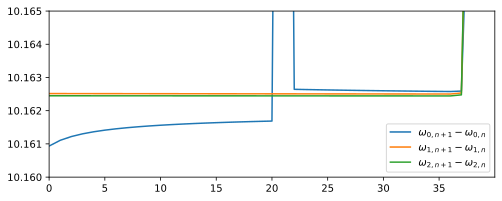

In [57]:
plt.figure(figsize = (8,3))
n_osc_lvls = max_ol-1
dressed_osc_frequencies = [[] for _ in range(3)]
for j in [0,1,2]:
    for i in range(0,max_ol-1):
        dressed_osc_frequencies[j].append(dressed_ener(j,i+1)-dressed_ener(j,i))
        
for j in [0,1,2]:
    plt.plot(list(range(max_ol-1))[:n_osc_lvls], dressed_osc_frequencies[j][:n_osc_lvls],label=rf'$\omega_{{{j},n+1}} - \omega_{{{j},n}}$')

plt.xticks(list(range(n_osc_lvls))[::5])
# plt.ylim(Er-0.002, Er+0.002)
plt.ylim(10.16,10.165)
plt.xlim(0,40)
# plt.xticklabels([str(i) for i in range(n_osc_lvls)])
plt.legend(loc='lower right')

In [59]:
def generate_excitation_array_1d(dims):
    arr = np.zeros(dims)
    for dim_index, dim_size in enumerate(dims):
        indices = [slice(None)] * len(dims)
        for level in range(dim_size):
            indices[dim_index] = level
            arr[tuple(indices)] += level
    flattened_arr = arr.flatten()
    return flattened_arr

def generate_single_mapping(H_with_interaction_no_drive) -> np.ndarray:
    """
    This function uses both the overlap (when dressed state is expressed in the product basis)
        and the total excitation number (each product state correspond to a total exictation number)
        to determine the mapping from dressed states to product states
    """

H_with_interaction_no_drive = system.hilbertspace.hamiltonian()


# 1)
evals, evecs = H_with_interaction_no_drive.eigenstates()
overlap_matrix = scqubits.utils.spectrum_utils.convert_evecs_to_ndarray(evecs)  # overlap_matrix[dressed_idx,product_idx] is the overlap. sum of overlap^2 is 1

# 2)
dims = H_with_interaction_no_drive.dims[0]
system_size = len(dims)
excitation_number_in_product_indices = generate_excitation_array_1d(dims)

def get_excitation_number_of_dressed_state(dressed_index):
    overlap_squared = overlap_matrix[dressed_index, :]**2
    return excitation_number_in_product_indices@overlap_squared

In [60]:
import itertools

product_state_names = list(itertools.product(*[range(dim) for dim in dims]))
product_index_map = {product: index for index, product in enumerate(product_state_names)}


total_dim = math.prod(dims)
dressed_indices_of_product_states = [None] * total_dim
product_to_dressed = {}


In [61]:
def print_numbers(product):
    product_index = product_index_map[product]

    sorted_overlaps_with_dressed_states = np.sort(np.abs(overlap_matrix[:, product_index])**2)[::-1]
    sorted_dressed_state_overlaps = np.argsort(np.abs(overlap_matrix[:, product_index]))[::-1]
    sorted_total_dressed_exitations = get_excitation_number_of_dressed_state(sorted_dressed_state_overlaps)

    product = product_state_names[product_index]
    ql, ol = product
    excitation_bare = ql+ol

    sorted_excitation_diff = sorted_total_dressed_exitations - excitation_bare

    print(sorted_overlaps_with_dressed_states[:8])
    print('\n')
    print(sorted_excitation_diff[:8])
    print('\n')
    print(sorted_dressed_state_overlaps[:8])
    print('\n')

In [66]:
print_numbers((0,4))

[7.39682739e-01 2.59551639e-01 4.26031121e-04 1.37858515e-04
 5.97542163e-05 5.62242303e-05 5.58982558e-05 9.11415782e-06]


[29.00002367+0.j 22.89504349+0.j  4.56179472+0.j 43.76065918+0.j
 -3.73804188+0.j 11.71976135+0.j  3.43135542+0.j 32.66956924+0.j]


[ 88  89  72 122  76  86  84 126]




In [62]:
print_numbers((0,15))

[5.48430243e-01 4.48790081e-01 1.58901976e-03 4.38912907e-04
 2.22755924e-04 2.08572867e-04 1.98223420e-04 2.89792491e-05]


[47.9987678 +0.j 13.78932624+0.j  1.34874978+0.j  2.66502211+0.j
 18.51710979+0.j 25.70325819+0.j  9.68847274+0.j 14.31489976+0.j]


[363 364 347 397 351 361 359 401]


